# Lab 6.02 - Regression analysis

In [1]:
# Package imports
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Dataframe
import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic plot
import seaborn as sns                               # Advanced dataviz
from sklearn.linear_model import LinearRegression

## Exercise 2: Flemish agricultural and horticultural businesses

1. Use the dataset agriculture flanders.csv. The file contains data about agricultural and horticultural businesses in Flanders

    Source: Departement Landbouw en Visserij op basis van StatBel

In [2]:
farms = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/agriculture%20flanders.csv', delimiter = ";", decimal=',')
# Show the first few records of the Data Frame
farms.head()

,year,number_of_farms,average_area_per_farm_(ha)
0,1980,75706,8.38
1,1981,73292,8.58
2,1982,71255,8.79
3,1983,69807,8.94
4,1984,68083,9.15


2. What are the datatypes for each of the columns.

In [6]:
# farms.info()
farms.dtypes

year                            int64
number_of_farms                 int64
average_area_per_farm_(ha)    float64
dtype: object

3. Draw a scatter plot of the number of farms versus the year.


<Axes: xlabel='year', ylabel='number_of_farms'>

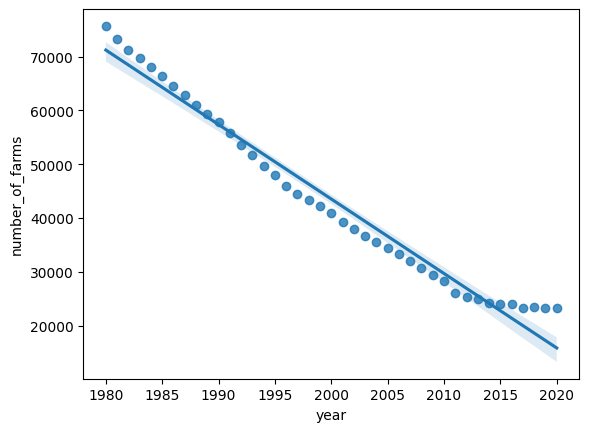

In [8]:
sns.regplot(data=farms,  x='year', y='number_of_farms')

4. Is there a positive / negative relationship between year and number_of_farms?

    $R = -0.9861066349492859$

In [10]:
cor = np.corrcoef(
    farms.year,
    farms.number_of_farms)[0][1]
print(f"R ≈ {cor}")

R ≈ -0.9861066349492859


> negative relationship (R $\lt$ 0) -> decreasing

6. Is there a strong relationship between year and 'number_of_farms'?

    $R^2 = 0.9724062954910041$

In [12]:
deter = cor ** 2
print(f"R² ≈ {deter}")

R² ≈ 0.9724062954910041


> exceptionally strong ($\gt$ 0.9)

7. Draw a scatter plot of the 'average_area_per_farm_(ha)' versus the year.

<Axes: xlabel='year', ylabel='average_area_per_farm_(ha)'>

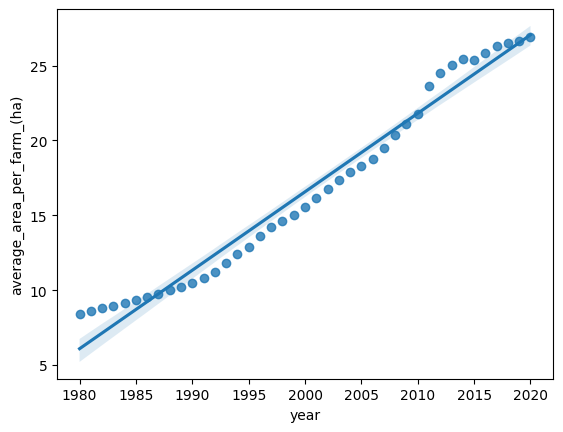

In [13]:
sns.regplot(data=farms,  x='year', y='average_area_per_farm_(ha)')

8. What will be the 'average_area_per_farm_(ha)' in 2035?

Average area in 2035 = 34.91987804878045

In [16]:
b1, b0 = np.polyfit(x=farms.year, y=farms['average_area_per_farm_(ha)'], deg=1)
print(f"Beta_0 = {b0:.5f}")
print(f"Beta_1 = {b1:.5f}")
print(f"Regression line: ŷ = {b0} + {b1}x")
print(f"ŷ = {b0} + {b1} * 2035 = {b0 + (b1 * 2035)}")

Beta_0 = -1031.89519
Beta_1 = 0.52423
Regression line: ŷ = -1031.8951916376452 + 0.5242334494773592x
ŷ = -1031.8951916376452 + 0.5242334494773592 * 2035 = 34.919878048780674


8. Calculate the total agricultural area for each year.   
Calculate for each year the change of the total area relative to 1980.  
Make a plot.

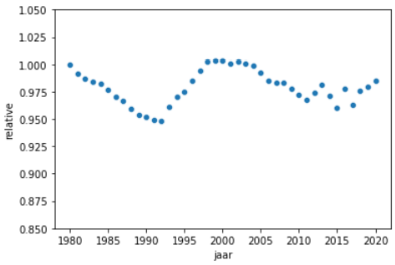


In [40]:
farms['total_area'] = farms['number_of_farms'] * farms['average_area_per_farm_(ha)']
farms['difference'] = farms['total_area'] / farms[farms['year'] == 1980]['total_area'][0]
farms.head(20)

,year,number_of_farms,average_area_per_farm_(ha),percentage,total_area,difference
0,1980,75706,8.38,1.000000,634416.28,1.000000
1,1981,73292,8.58,0.976690,628845.36,0.991219
2,1982,71255,8.79,0.953356,626331.45,0.987256
3,1983,69807,8.94,0.937360,624074.58,0.983699
4,1984,68083,9.15,0.915847,622959.45,0.981941
5,1985,66408,9.33,0.898178,619586.64,0.976625
6,1986,64624,9.53,0.879328,615866.72,0.970761
7,1987,62814,9.76,0.858607,613064.64,0.966344
8,1988,60983,9.98,0.839679,608610.34,0.959323
9,1989,59365,10.19,0.822375,604929.35,0.953521


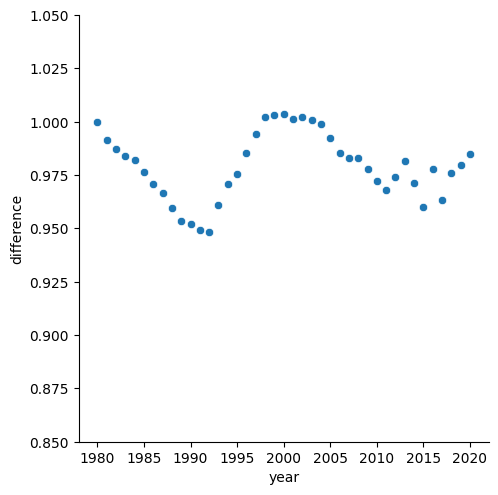

In [42]:
plot = sns.relplot(x=farms.year, y=farms.difference)
plot.set(ylim=(0.85, 1.05))